# 🍔 Proyecto Integrador: Pipeline ETL & Inteligencia de Mercado (Food Delivery)
- **Curso:** Python for Data Analyst
- **Autor:** Sebastian Aldana Pachas

### 📦 Instalación de librerías
Instalo SQLAlchemy (la uso en la Parte 3) y Seaborn (la uso en la Parte 4) porque no vienen instaladas en el compute serverless de Databricks Free.

In [0]:
%pip install sqlalchemy seaborn

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# 📥 Parte 1 - Extracción y Diagnóstico (Extract)
Lectura de los archivos .CSV con Pandas y análisis exploratorio inicial (data profiling).

In [0]:
import pandas as pd  # librería principal para trabajar con tablas
import glob          # para buscar todos los archivos de una carpeta

# Ruta del Volume donde subí los archivos CSV. La guardo en una variable
# para cambiarla en un solo lugar si algún día cambia la carpeta
RUTA_BASE = "/Volumes/workspace/default/delivery_data"

### 📂 Consigna 1: Carga de los archivos CSV
Cargo los dos archivos en DataFrames de Pandas: `df_restaurantes` (catálogo de restaurantes) y `df_menus` (detalle de los platos). El menú viene dividido en 10 archivos, así que los leo todos y los uno en un solo DataFrame.

In [0]:
# Consigna 1: cargar el catálogo de restaurantes en df_restaurantes
df_restaurantes = pd.read_csv(f"{RUTA_BASE}/restaurants/restaurants.csv")

# Imprimo las columnas porque los nombres reales pueden ser distintos a los
# del enunciado (aquí vienen en inglés, ej: price_range y full_address)
print("Columnas:", list(df_restaurantes.columns))
df_restaurantes.head()  # vista rápida de las primeras 5 filas

Columnas: ['id', 'position', 'name', 'score', 'ratings', 'category', 'price_range', 'full_address', 'zip_code', 'lat', 'lng']


,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,$,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700


In [0]:
# Consigna 1: cargar el detalle de menús en df_menus
# En mi copia del dataset el menú viene en 10 archivos, así que los leo
# todos y luego los uno en un solo DataFrame

archivos_menus = sorted(glob.glob(f"{RUTA_BASE}/restaurant-menus/*.csv"))  # sorted() para que el orden siempre sea el mismo
print("Archivos encontrados:", len(archivos_menus))

partes = []           # aquí voy guardando cada archivo leído
columnas_ref = None   # columnas del primer archivo, para comparar con los demás

for ruta in archivos_menus:
    parte = pd.read_csv(ruta)

    if columnas_ref is None:
        columnas_ref = list(parte.columns)  # tomo el primer archivo como referencia

    # Verifico que todos tengan las mismas columnas: si uno viniera distinto,
    # al unirlos se mezclarían datos sin darme ningún aviso
    mismas_columnas = list(parte.columns) == columnas_ref

    print(f"{ruta.split('/')[-1]}  ->  {parte.shape}  | mismas columnas: {mismas_columnas}")
    partes.append(parte)

df_menus = pd.concat(partes, ignore_index=True)  # ignore_index evita números de fila repetidos
del partes  # ya están dentro de df_menus, libero la memoria

print("\nDimensiones totales de df_menus:", df_menus.shape)
df_menus.head()

Archivos encontrados: 10
restaurant_menus_parte_01.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_02.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_03.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_04.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_05.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_06.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_07.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_08.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_09.csv  ->  (83635, 5)  | mismas columnas: True
restaurant_menus_parte_10.csv  ->  (83635, 5)  | mismas columnas: True

Dimensiones totales de df_menus: (836350, 5)


,restaurant_id,category,name,description,price
0,1,Extra Large Pizza,Extra Large Meat Lovers,Whole pie.,15.99 USD
1,1,Extra Large Pizza,Extra Large Supreme,Whole pie.,15.99 USD
2,1,Extra Large Pizza,Extra Large Pepperoni,Whole pie.,14.99 USD
3,1,Extra Large Pizza,Extra Large BBQ Chicken &amp; Bacon,Whole Pie,15.99 USD
4,1,Extra Large Pizza,Extra Large 5 Cheese,Whole pie.,14.99 USD


### 🔎 Consigna 2: Análisis exploratorio (Data Profiling)
Reviso las dimensiones (`.shape`), los tipos de datos (`.dtypes`) y los valores nulos de ambos DataFrames para saber qué debo limpiar.

In [0]:
# Consigna 2: Data Profiling de ambos DataFrames
# Uso un solo bucle para revisar los dos DataFrames igual y no repetir código
for nombre, df in [("df_restaurantes", df_restaurantes), ("df_menus", df_menus)]:
    print("=" * 50)
    print(f"📊 {nombre}")
    print("=" * 50)

    print("Dimensiones (.shape):", df.shape)  # filas y columnas, para comparar después de limpiar

    print("\nTipos de datos (.dtypes):")
    print(df.dtypes)  # veo si hay números guardados como texto, como "price"

    print("\nValores nulos por columna:")
    print(df.isnull().sum())  # me dice qué columnas tengo que limpiar
    print()

📊 df_restaurantes
Dimensiones (.shape): (63469, 11)

Tipos de datos (.dtypes):
id                int64
position          int64
name             object
score           float64
ratings         float64
category         object
price_range      object
full_address     object
zip_code         object
lat             float64
lng             float64
dtype: object

Valores nulos por columna:
id                  0
position            0
name                0
score           28167
ratings         28167
category           85
price_range     10617
full_address      453
zip_code          517
lat                 0
lng                 0
dtype: int64

📊 df_menus
Dimensiones (.shape): (836350, 5)

Tipos de datos (.dtypes):
restaurant_id     int64
category         object
name             object
description      object
price            object
dtype: object

Valores nulos por columna:
restaurant_id         0
category              0
name                  1
description      200324
price                 0
dtype

### 🔎 Conclusiones del diagnóstico (Parte 1):
- **df_restaurantes:** 63,469 filas y 11 columnas. `score` y `ratings` tienen 28,167 nulos cada una (44 %), `price_range` tiene 10,617 (17 %) y `full_address` tiene 453.
- **df_menus:** 836,350 filas y 5 columnas. `price` viene como texto (object) y debo convertirlo a número. `description` tiene 200,324 nulos, pero no la necesito para el análisis.

# 🧹 Parte 2 - Ingeniería de Características y Limpieza (Transform)
## En df_restaurantes

### 💲 Consigna 1: Mapeo de precios
`price_range` trae símbolos (`$`, `$$`, `$$$`, `$$$$`). Primero reviso qué valores existen realmente y después los cambio por texto con un diccionario y `.map()`. Encontré un caso con 17 símbolos `$`, que es un dato erróneo: no lo mapeo y queda como nulo.

In [0]:
# Revisión previa de la Consigna 1: reviso qué valores tiene price_range
# por si hay alguno inesperado antes de mapear
df_restaurantes["price_range"].value_counts(dropna=False)  # dropna=False para ver también los nulos

price_range
$                    37637
$$                   14952
NaN                  10617
$$$                    237
$$$$                    25
$$$$$$$$$$$$$$$$$        1
Name: count, dtype: int64

In [0]:
# Consigna 1: Mapeo de precios
# Diccionario con los 4 niveles que pide el enunciado
mapa_precios = {
    "$": "Económico",
    "$$": "Moderadamente caro",
    "$$$": "Caro",
    "$$$$": "Muy caro"
}

# .map() cambia cada símbolo por su texto. Lo que no está en el diccionario
# queda como NaN: el caso de los 17 "$" y los nulos que ya existían
df_restaurantes["price_range"] = df_restaurantes["price_range"].map(mapa_precios)

# Verifico que el mapeo quedó bien
df_restaurantes["price_range"].value_counts(dropna=False)  # dropna=False para ver los nulos

price_range
Económico             37637
Moderadamente caro    14952
NaN                   10618
Caro                    237
Muy caro                 25
Name: count, dtype: int64

### 📍 Consigna 2: Desanidado de ubicaciones
Al revisar `full_address` vi que el 3 % de las direcciones tiene comas de más (por ejemplo `Suite 4`). Un `.str.split(',')` normal habría desordenado la ciudad en esas filas, así que corté desde la derecha con `.str.rsplit(',', n=3)`: las últimas tres partes son ciudad, estado y código postal, y lo demás es la calle.

In [0]:
# Revisión previa de la Consigna 2: cuento cuántas comas tiene cada dirección
# Si no todas tienen las mismas, el split podría desordenar las columnas
df_restaurantes["full_address"].str.count(",").value_counts(dropna=False)  # dropna=False para ver también los nulos

full_address
3.0     61155
4.0      1544
NaN       453
5.0       296
6.0        12
7.0         4
8.0         3
9.0         1
11.0        1
Name: count, dtype: int64

In [0]:
# Reviso cómo son las direcciones con comas de más antes de decidir cómo separarlas
extra = df_restaurantes[df_restaurantes["full_address"].str.count(",") > 3]  # solo las que se salen del patrón

print("Muestra al azar:")
print(extra["full_address"].sample(8, random_state=42).tolist())  # random_state para ver siempre la misma muestra

print("\nLa más larga (11 comas):")
print(df_restaurantes[df_restaurantes["full_address"].str.count(",") == 11]["full_address"].tolist())

Muestra al azar:
['10417 Gravelly Lake Dr SW, Ste B, Lakewood, WA, 98499', '739 Lynnhaven PWKY, Suite 100, Virginia Beach, VA, 23452', '205 West Nolana Loop, Suite 3, San Juan, TX, 78589', '1121 Uptown Park Boulevard, Suite 4, Houston, TX, 77056', '3013 Georgia Avenue Northwest, 1st Floor, Washington, DC, 20001', '23320 Mercantile Pkwy, Katy, USA, Houston, TX, 77449', '12202 Almeda Road, SUITE A, Houston, TX, 77045', '3390 South State Street, Unit 12, South Salt Lake, UT, 84115']

La más larga (11 comas):
['Zona Libre de Comercio #61, Carretera 165, Edificio 1, Local 1, A1-14, Guaynabo, PR 00965, Guaynabo, Guaynabo 00965 United States, San Juan, , 00920']


In [0]:
# Consigna 2: Desanidado de ubicaciones (Split)
# Corto desde la derecha con rsplit en 3 comas: las 3 últimas partes siempre son
# ciudad, estado y código postal, y lo que queda a la izquierda es la calle completa
partes = df_restaurantes["full_address"].str.rsplit(",", n=3, expand=True)  # me da 4 columnas: calle, ciudad, estado, zip

df_restaurantes["calle"] = partes[0].str.strip()
df_restaurantes["ciudad"] = partes[1].str.strip()  # strip quita los espacios ocultos, como pide el enunciado
df_restaurantes["estado_zip"] = partes[2].str.strip() + " " + partes[3].str.strip()  # ej: "TX 77056"

del partes  # ya no la necesito, libero memoria

# Verificaciones
print("Nulos en ciudad (deberían ser 453):", df_restaurantes["ciudad"].isnull().sum())
df_restaurantes[["full_address", "calle", "ciudad", "estado_zip"]].head()

Nulos en ciudad (deberían ser 453): 453


,full_address,calle,ciudad,estado_zip
0,"224 Daniel Payne Drive, Birmingham, AL, 35207",224 Daniel Payne Drive,Birmingham,AL 35207
1,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",1521 Pinson Valley Parkway,Birmingham,AL 35217
2,"541-B Graymont Ave, Birmingham, AL, 35204",541-B Graymont Ave,Birmingham,AL 35204
3,"1580 Montgomery Highway, Hoover, AL, 35226",1580 Montgomery Highway,Hoover,AL 35226
4,"314 17th St N, Birmingham, AL, 35203",314 17th St N,Birmingham,AL 35203


### ⭐ Consigna 3: Filtro de calidad
Elimino los restaurantes sin puntaje (nulo o 0) y paso la categoría a minúsculas.

In [0]:
# Consigna 3: Filtro de calidad
filas_antes = len(df_restaurantes)  # para medir cuántas filas se pierden
print("Score nulo:", df_restaurantes["score"].isnull().sum())
print("Score igual a 0:", (df_restaurantes["score"] == 0).sum())  # reviso los ceros porque el enunciado también los excluye

# Me quedo solo con los que tienen score válido (no nulo y distinto de 0)
df_restaurantes = df_restaurantes[
    df_restaurantes["score"].notnull() & (df_restaurantes["score"] != 0)
].copy()  # .copy() evita advertencias de pandas cuando modifico el resultado después

# Estandarizo category a minúsculas (los nulos se mantienen como nulos)
df_restaurantes["category"] = df_restaurantes["category"].str.lower()

# Resumen del filtro
print("\nFilas antes:", filas_antes)
print("Filas después:", len(df_restaurantes))
print("Filas eliminadas:", filas_antes - len(df_restaurantes))

# Reviso qué nulos me quedan en las columnas que usaré más adelante
print("\nNulos que quedan:")
print(df_restaurantes[["ratings", "ciudad", "price_range"]].isnull().sum())

Score nulo: 28167
Score igual a 0: 0

Filas antes: 63469
Filas después: 35302
Filas eliminadas: 28167

Nulos que quedan:
ratings           0
ciudad          190
price_range    4610
dtype: int64


## En df_menus
### 💲 Consigna 1: Limpieza del precio
`price` viene como texto (ej. `15.99 USD`). Quito el texto " USD", cambio la coma por punto (por si acaso) y lo convierto a número decimal (float).

In [0]:
# Consigna 1 (df_menus): convertir price de texto a número (float)
# Convierto en una variable aparte primero, para revisar si algo falla
# antes de modificar la columna original
precio_num = pd.to_numeric(
    df_menus["price"].astype(str)                   # astype(str) por si la celda se ejecuta dos veces
        .str.replace(" USD", "", regex=False)       # quito el texto " USD"
        .str.replace(",", ".", regex=False)         # coma por punto, como pide el enunciado
        .str.strip(),                               # quito espacios sobrantes
    errors="coerce"                                 # lo que no se pueda convertir queda NaN, no da error
)

# Si algún valor no se pudo convertir, aparece aquí
print("Precios que no se pudieron convertir:", precio_num.isnull().sum())

df_menus["price"] = precio_num.astype(float)  # ahora sí reemplazo la columna original

print("Tipo de dato de price:", df_menus["price"].dtype)
df_menus["price"].describe()  # mínimo y máximo para detectar precios absurdos

Precios que no se pudieron convertir: 0
Tipo de dato de price: float64


count    836350.000000
mean          9.899025
std          11.534377
min          -7.050000
25%           3.950000
50%           7.990000
75%          12.990000
max        1099.990000
Name: price, dtype: float64

### 🚫 Consigna 2: Eliminar precios en cero o nulos
Al revisar `price` vi que además de los ceros hay precios negativos, que no tienen sentido. Por eso filtro con `price > 0`, que quita ceros, negativos y nulos de una sola vez.

In [0]:
# Consigna 2 (df_menus): eliminar ítems con precio 0 o nulo
# Antes cuento cada caso para tener evidencia de qué se elimina
print("Precios nulos:", df_menus["price"].isnull().sum())
print("Precios iguales a 0:", (df_menus["price"] == 0).sum())
print("Precios negativos:", (df_menus["price"] < 0).sum())  # no los pide el enunciado, pero no tienen sentido

filas_antes = len(df_menus)  # para medir cuántas filas se pierden

# price > 0 deja solo los precios válidos: un nulo nunca cumple la condición
df_menus = df_menus[df_menus["price"] > 0].copy()  # .copy() evita advertencias de pandas después

print("\nFilas antes:", filas_antes)
print("Filas después:", len(df_menus))
print("Filas eliminadas:", filas_antes - len(df_menus))

df_menus["price"].describe()  # confirmo que el mínimo ya es mayor que 0

Precios nulos: 0
Precios iguales a 0: 37551
Precios negativos: 2

Filas antes: 836350
Filas después: 798797
Filas eliminadas: 37553


count    798797.000000
mean         10.364415
std          11.596233
min           0.010000
25%           4.390000
50%           8.380000
75%          13.190000
max        1099.990000
Name: price, dtype: float64

## Optimización y Cruce (Control de Memoria RAM)
### 🔽 Consigna 1: Restaurantes consolidados
Filtro `df_restaurantes` para quedarme solo con los que tienen más de 100 calificaciones. Lo hago antes del cruce para que el merge trabaje con menos filas y use menos memoria.

In [0]:
# Consigna 1 (Optimización): quedarme solo con restaurantes consolidados (más de 100 ratings)
filas_antes = len(df_restaurantes)  # para medir cuántos restaurantes se pierden

# Estrictamente mayor que 100, como dice el enunciado ("más de 100")
df_restaurantes = df_restaurantes[df_restaurantes["ratings"] > 100].copy()  # .copy() evita advertencias después

print("Restaurantes antes:", filas_antes)
print("Restaurantes después (consolidados):", len(df_restaurantes))

# Reviso que cada restaurante aparezca una sola vez: si hubiera ids repetidos,
# el merge duplicaría sus platos y los conteos saldrían inflados
print("¿id único?:", df_restaurantes["id"].is_unique)

# Nulos que me quedan en las columnas que usaré en la Parte 4
print("\nNulos que quedan:")
print(df_restaurantes[["ciudad", "price_range", "category"]].isnull().sum())

Restaurantes antes: 35302
Restaurantes después (consolidados): 8702
¿id único?: True

Nulos que quedan:
ciudad          29
price_range    630
category         3
dtype: int64


### 🔗 Consigna 2: Cruce de restaurantes y menús (INNER JOIN)
Uno los restaurantes consolidados con sus platos usando el id del restaurante. Quito `description` (no la uso en el análisis) y uso sufijos porque `category` y `name` existen en ambas tablas.

In [0]:
# Consigna 2 (Cruce): INNER JOIN entre restaurantes consolidados y menús
# Quito description antes del cruce para que df_master pese menos:
# tiene 24 % de nulos y no la uso en ninguna de las 4 preguntas
menus_cruce = df_menus.drop(columns=["description"])

df_master = pd.merge(
    df_restaurantes,
    menus_cruce,
    how="inner",                          # solo quedan restaurantes que tienen platos
    left_on="id",                         # el id del restaurante tiene distinto nombre en cada tabla
    right_on="restaurant_id",
    suffixes=("_restaurante", "_menu"),   # category y name están en ambas tablas
    validate="one_to_many"                # un restaurante, muchos platos: da error si id se repitiera
)

df_master = df_master.drop(columns=["restaurant_id"])  # repite id, no la necesito
del menus_cruce                                        # libero memoria

# Verificaciones del cruce
con_menu = df_master["id"].nunique()  # restaurantes distintos que sí tienen platos
print("Filas de df_master (platos):", len(df_master))
print("Restaurantes en df_master:", con_menu)
print("Restaurantes consolidados sin platos (se pierden en el inner join):", len(df_restaurantes) - con_menu)
print("\nColumnas:", list(df_master.columns))
df_master.head()

Filas de df_master (platos): 63221
Restaurantes en df_master: 671
Restaurantes consolidados sin platos (se pierden en el inner join): 8031

Columnas: ['id', 'position', 'name_restaurante', 'score', 'ratings', 'category_restaurante', 'price_range', 'full_address', 'zip_code', 'lat', 'lng', 'calle', 'ciudad', 'estado_zip', 'category_menu', 'name_menu', 'price']


,id,position,name_restaurante,score,ratings,category_restaurante,price_range,full_address,zip_code,lat,lng,calle,ciudad,estado_zip,category_menu,name_menu,price
0,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,WI 53221,Picked for you,Spring Roll,6.99
1,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,WI 53221,Picked for you,Egg Roll,6.50
2,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,WI 53221,Picked for you,Grilled Pork,9.50
3,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,WI 53221,Picked for you,House Special,10.95
4,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",Económico,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,4756 S 27th St,Milwaukee,WI 53221,Picked for you,Rice Noodle with Rare Steak,10.95


### ⚠️ Nota sobre la cobertura de los menús
Después del cruce, `df_master` quedó con **671 restaurantes** (63,221 platos), no con los 8,702 consolidados. Revisé la causa: los menús entregados cubren solo los `restaurant_id` del 1 al 10,082, y la mayoría de los restaurantes consolidados tiene un id mayor. Los datos son los entregados por el curso, así que continúo con ellos y tengo presente que las conclusiones de la Parte 4 describen esta muestra de 671 restaurantes.

In [0]:
# Verificación del cruce: reviso por qué solo 671 restaurantes tienen platos
print("Restaurantes distintos en df_menus:", df_menus["restaurant_id"].nunique())
print("Rango de restaurant_id en df_menus:", df_menus["restaurant_id"].min(), "-", df_menus["restaurant_id"].max())
print("Rango de id en df_restaurantes (consolidados):", df_restaurantes["id"].min(), "-", df_restaurantes["id"].max())

# Cuántos consolidados caen dentro del rango de ids que tienen menú
print("Consolidados con id <= máximo id de los menús:",
      (df_restaurantes["id"] <= df_menus["restaurant_id"].max()).sum())

Restaurantes distintos en df_menus: 9962
Rango de restaurant_id en df_menus: 1 - 10082
Rango de id en df_restaurantes (consolidados): 1739 - 63427
Consolidados con id <= máximo id de los menús: 675


# 💾 Parte 3 - Carga a Base de Datos (Load)
Creo la base de datos SQLite `delivery_insights.db` con SQLAlchemy y cargo la tabla final `master_food_data`.

### 🔌 Consigna 1: Motor de base de datos SQLite
Importo SQLAlchemy y creo el motor (`create_engine`) para la base `delivery_insights.db`. La creo en el disco local de Databricks (`/tmp`) porque SQLite necesita escribir y bloquear el archivo todo el tiempo, y eso no funciona bien directamente sobre el Volume. Al final dejo una copia en el Volume para no perderla cuando termine la sesión.

In [0]:
from sqlalchemy import create_engine, text  # create_engine crea la conexión; text lo uso para las consultas SQL

# Consigna 1: crear el motor de la base de datos SQLite
# Uso /tmp (disco local) porque SQLite escribe y bloquea el archivo todo el tiempo
engine = create_engine("sqlite:////tmp/delivery_insights.db")  # cuatro barras: "sqlite:///" + ruta que empieza con "/"

print("Motor creado:", engine.url)  # confirmo la ruta de la base

Motor creado: sqlite:////tmp/delivery_insights.db


### 📥 Consigna 2: Carga de la tabla final
Cargo `df_master` en la tabla `master_food_data` con `to_sql()`, usando `if_exists="replace"` e `index=False`. Cada fila de esta tabla es un plato, no un restaurante, y lo tendré presente en las consultas de la Parte 4.

In [0]:
# Consigna 2: cargar df_master en la tabla master_food_data
df_master.to_sql(
    "master_food_data",
    engine,
    if_exists="replace",  # si la tabla ya existe la reemplaza, así puedo correr la celda varias veces
    index=False,          # no guardo el índice de pandas como una columna más
    chunksize=20_000      # carga por tandas para no usar tanta memoria de una vez
)

print("Tabla master_food_data cargada")

Tabla master_food_data cargada


### ✅ Verificación de la carga
Compruebo que la tabla tiene las mismas filas que `df_master` y dejo una copia de la base en el Volume.

In [0]:
import shutil  # para copiar archivos con Python
import os      # para revisar el tamaño del archivo copiado

# Verifico la carga: cuento las filas directamente desde la base de datos
with engine.connect() as conn:  # "with" cierra la conexión solo al terminar
    filas = pd.read_sql(text("SELECT COUNT(*) AS filas FROM master_food_data"), conn)

print("Filas en master_food_data:", filas["filas"][0])
print("Filas en df_master:", len(df_master))  # deben ser iguales

# Guardo una copia en el Volume, porque el contenido de /tmp se borra al terminar la sesión
# Uso shutil y no dbutils.fs.cp porque el compute serverless no deja a dbutils leer /tmp
destino = f"{RUTA_BASE}/delivery_insights.db"
shutil.copy("/tmp/delivery_insights.db", destino)  # copia el archivo completo, sin escribirlo por partes

print("Copia guardada en:", destino)
print("Tamaño de la copia:", round(os.path.getsize(destino) / 1_000_000, 1), "MB")  # confirma que no quedó vacía

Filas en master_food_data: 63221
Filas en df_master: 63221
Copia guardada en: /Volumes/workspace/default/delivery_data/delivery_insights.db
Tamaño de la copia: 16.9 MB


# 📊 Parte 4 - Business Intelligence: Reporte al CEO (SQL + Visualización)
Leo la base `delivery_insights.db` con `pd.read_sql(text(query), conn)` y respondo las 4 preguntas del CEO. En cada una muestro el query, el DataFrame resultante, un gráfico y una conclusión. Cada fila de `master_food_data` es un plato, así que para contar restaurantes uso `COUNT(DISTINCT id)` y no `COUNT(*)`.

In [0]:
import matplotlib.pyplot as plt  # base de los gráficos
import seaborn as sns            # gráficos más limpios y con mejor estilo

sns.set_theme(style="whitegrid")  # fondo claro con líneas guía, se lee mejor en un reporte

### 🌎 Pregunta 1: Penetración geográfica
¿Cuáles son las 5 ciudades con más restaurantes consolidados en nuestra base?

In [0]:
# Pregunta 1: top 5 ciudades por cantidad de restaurantes
query_q1 = """
SELECT
    ciudad,
    COUNT(DISTINCT id) AS restaurantes,  -- restaurantes distintos, no platos
    COUNT(*)           AS platos         -- solo para comparar y ver por qué no uso COUNT(*)
FROM master_food_data
WHERE ciudad IS NOT NULL                 -- descarto las filas sin ciudad
GROUP BY ciudad
ORDER BY restaurantes DESC, ciudad ASC   -- ciudad ASC desempata siempre igual si hay empates
LIMIT 5
"""

print(query_q1)  # muestro el query ejecutado, como pide el enunciado

with engine.connect() as conn:  # "with" cierra la conexión solo al terminar
    df_q1 = pd.read_sql(text(query_q1), conn)

df_q1


SELECT
    ciudad,
    COUNT(DISTINCT id) AS restaurantes,  -- restaurantes distintos, no platos
    COUNT(*)           AS platos         -- solo para comparar y ver por qué no uso COUNT(*)
FROM master_food_data
WHERE ciudad IS NOT NULL                 -- descarto las filas sin ciudad
GROUP BY ciudad
ORDER BY restaurantes DESC, ciudad ASC   -- ciudad ASC desempata siempre igual si hay empates
LIMIT 5



,ciudad,restaurantes,platos
0,Milwaukee,123,11834
1,Seattle,119,9663
2,Lynnwood,42,3673
3,Everett,32,2771
4,Bellevue,30,2642


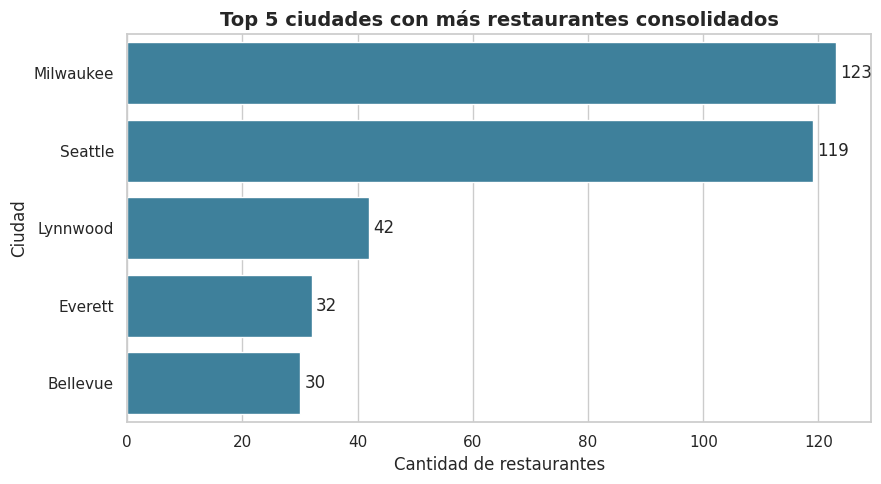

In [0]:
# Gráfico de barras horizontal: la primera fila del DataFrame (la mayor) queda arriba
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_q1, x="restaurantes", y="ciudad", color="#2E86AB")
ax.bar_label(ax.containers[0], padding=3)  # el número al final de cada barra, para leerlo sin adivinar

plt.title("Top 5 ciudades con más restaurantes consolidados", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de restaurantes")
plt.ylabel("Ciudad")
plt.tight_layout()  # evita que se corten los textos
plt.show()

💡 **Conclusión para el CEO:** Milwaukee (123) y Seattle (119) lideran con amplia ventaja y reúnen el 36 % de los 669 restaurantes con ciudad, aunque la muestra se concentra en Washington y Wisconsin, así que el ranking refleja esas zonas.

#### 🔍 Verificación de datos de la Pregunta 1
Antes de escribir la conclusión comprobé dos cosas: que ninguna ciudad del top 5 se repite en más de un estado, y cuántos restaurantes tienen ciudad (669 de los 671).

In [0]:
# Verificación: reviso si alguna ciudad del top 5 se repite en más de un estado
query_check = """
SELECT
    ciudad,
    SUBSTR(estado_zip, 1, 2) AS estado,  -- las 2 primeras letras de estado_zip, ej: "WA 98201" -> WA
    COUNT(DISTINCT id) AS restaurantes
FROM master_food_data
WHERE ciudad IN ('Milwaukee', 'Seattle', 'Lynnwood', 'Everett', 'Bellevue')
GROUP BY ciudad, estado
ORDER BY ciudad, restaurantes DESC
"""

with engine.connect() as conn:
    df_check = pd.read_sql(text(query_check), conn)

df_check

,ciudad,estado,restaurantes
0,Bellevue,WA,30
1,Everett,WA,32
2,Lynnwood,WA,42
3,Milwaukee,WI,123
4,Seattle,WA,119


In [0]:
# Verificación: cuántos de los restaurantes del cruce tienen ciudad
query_total = """
SELECT
    COUNT(DISTINCT id) AS total_restaurantes,                                 -- los 671 del cruce
    COUNT(DISTINCT CASE WHEN ciudad IS NOT NULL THEN id END) AS con_ciudad    -- los que sí tienen ciudad
FROM master_food_data
"""

with engine.connect() as conn:
    df_total = pd.read_sql(text(query_total), conn)

df_total

,total_restaurantes,con_ciudad
0,671,669


#### 🗺️ Cobertura geográfica de la muestra
Revisé en qué estados están los 671 restaurantes: 466 en Washington, 177 en Wisconsin, 25 en Illinois, 1 en Oregón y 2 sin dato de estado. Por eso el ranking de ciudades de la Pregunta 1 refleja las zonas que cubre la muestra y no necesariamente todo el mercado de Estados Unidos.

In [0]:
# Verificación: cuántos restaurantes de la muestra hay en cada estado
query_estados = """
SELECT
    SUBSTR(estado_zip, 1, 2) AS estado,  -- las 2 primeras letras de estado_zip, ej: "WA 98201" -> WA
    COUNT(DISTINCT id)       AS restaurantes,
    COUNT(DISTINCT ciudad)   AS ciudades
FROM master_food_data
GROUP BY estado
ORDER BY restaurantes DESC
"""

with engine.connect() as conn:
    df_estados = pd.read_sql(text(query_estados), conn)

df_estados

,estado,restaurantes,ciudades
0,WA,466,36
1,WI,177,19
2,IL,25,8
3,None,2,0
4,OR,1,1


### 💰 Pregunta 2: Análisis de oportunidad de precio
El CEO cree que todos los restaurantes del mercado son caros. Cuento cuántos restaurantes hay en cada rango de precio.

In [0]:
# Pregunta 2: distribución de restaurantes por rango de precio
query_q2 = """
SELECT
    COALESCE(price_range, 'Sin dato') AS rango_de_precios,  -- los nulos aparecen como "Sin dato" y no desaparecen
    COUNT(DISTINCT id) AS restaurantes,                     -- restaurantes distintos, no platos
    ROUND(100.0 * COUNT(DISTINCT id)
          / (SELECT COUNT(DISTINCT id) FROM master_food_data), 1) AS porcentaje  -- sobre el total de restaurantes
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY CASE rango_de_precios                              -- orden lógico, no alfabético
    WHEN 'Económico' THEN 1
    WHEN 'Moderadamente caro' THEN 2
    WHEN 'Caro' THEN 3
    WHEN 'Muy caro' THEN 4
    ELSE 5 END
"""

print(query_q2)  # muestro el query ejecutado

with engine.connect() as conn:
    df_q2 = pd.read_sql(text(query_q2), conn)

df_q2


SELECT
    COALESCE(price_range, 'Sin dato') AS rango_de_precios,  -- los nulos aparecen como "Sin dato" y no desaparecen
    COUNT(DISTINCT id) AS restaurantes,                     -- restaurantes distintos, no platos
    ROUND(100.0 * COUNT(DISTINCT id)
          / (SELECT COUNT(DISTINCT id) FROM master_food_data), 1) AS porcentaje  -- sobre el total de restaurantes
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY CASE rango_de_precios                              -- orden lógico, no alfabético
    WHEN 'Económico' THEN 1
    WHEN 'Moderadamente caro' THEN 2
    WHEN 'Caro' THEN 3
    WHEN 'Muy caro' THEN 4
    ELSE 5 END



,rango_de_precios,restaurantes,porcentaje
0,Económico,450,67.1
1,Moderadamente caro,157,23.4
2,Caro,4,0.6
3,Sin dato,60,8.9


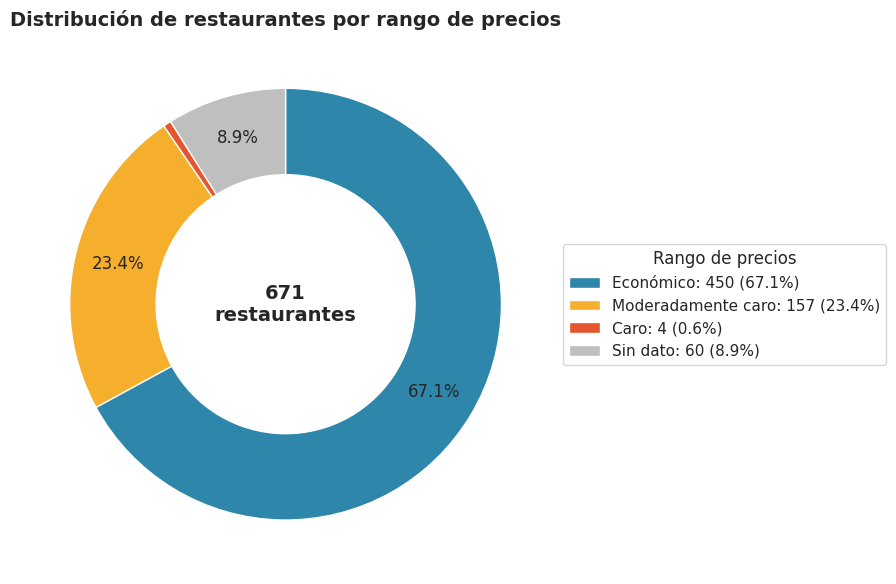

In [0]:
# Colores fijos por categoría: el gris queda reservado para "Sin dato"
colores = {
    "Económico": "#2E86AB",
    "Moderadamente caro": "#F6AE2D",
    "Caro": "#E4572E",
    "Muy caro": "#7B1E1E",
    "Sin dato": "#BFBFBF"
}

fig, ax = plt.subplots(figsize=(9, 6))

wedges, textos, porcentajes = ax.pie(
    df_q2["restaurantes"],
    colors=[colores[r] for r in df_q2["rango_de_precios"]],
    startangle=90,
    counterclock=False,                                # los trozos siguen el orden de la tabla
    wedgeprops={"width": 0.4, "edgecolor": "white"},   # width < 1 convierte la torta en donut
    autopct=lambda p: f"{p:.1f}%" if p >= 5 else "",   # oculto el % de los trozos muy chicos para que no se encimen
    pctdistance=0.8
)

# Leyenda con la cantidad y el porcentaje exacto de cada categoría
etiquetas = [
    f"{fila.rango_de_precios}: {fila.restaurantes} ({fila.porcentaje}%)"
    for fila in df_q2.itertuples()
]
ax.legend(wedges, etiquetas, title="Rango de precios", loc="center left", bbox_to_anchor=(1, 0.5))

# Total en el centro del donut
ax.text(0, 0, f"{df_q2['restaurantes'].sum()}\nrestaurantes",
        ha="center", va="center", fontsize=14, fontweight="bold")

plt.title("Distribución de restaurantes por rango de precios", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

💡 **Conclusión para el CEO:** La idea de que todo es caro no se cumple, el 67 % de los restaurantes es Económico y el 23 % Moderadamente caro; solo 4 son Caros y ninguno Muy caro. Hay 60 restaurantes (9 %) sin rango de precio.

### 🍽️ Pregunta 3: Estrategia de menú por ciudad
Para las 3 ciudades con más restaurantes (Pregunta 1), calculo el precio promedio de los platos del menú para ver en cuál es más caro comer.

In [0]:
# Pregunta 3: precio promedio de los platos en las 3 ciudades más populares
query_q3 = """
WITH top_ciudades AS (                        -- primero obtengo las 3 ciudades con más restaurantes
    SELECT ciudad
    FROM master_food_data
    WHERE ciudad IS NOT NULL
    GROUP BY ciudad
    ORDER BY COUNT(DISTINCT id) DESC, ciudad ASC   -- mismo criterio que en la Pregunta 1
    LIMIT 3
)
SELECT
    ciudad,
    ROUND(AVG(price), 2) AS precio_promedio,  -- lo que pide la pregunta
    COUNT(*)             AS platos,           -- cuántos platos entran en cada promedio
    MAX(price)           AS precio_maximo     -- para detectar si un plato muy caro infla el promedio
FROM master_food_data
WHERE ciudad IN (SELECT ciudad FROM top_ciudades)
GROUP BY ciudad
ORDER BY precio_promedio DESC                 -- la primera fila es la ciudad más cara
"""

print(query_q3)  # muestro el query ejecutado

with engine.connect() as conn:
    df_q3 = pd.read_sql(text(query_q3), conn)

df_q3


WITH top_ciudades AS (                        -- primero obtengo las 3 ciudades con más restaurantes
    SELECT ciudad
    FROM master_food_data
    WHERE ciudad IS NOT NULL
    GROUP BY ciudad
    ORDER BY COUNT(DISTINCT id) DESC, ciudad ASC   -- mismo criterio que en la Pregunta 1
    LIMIT 3
)
SELECT
    ciudad,
    ROUND(AVG(price), 2) AS precio_promedio,  -- lo que pide la pregunta
    COUNT(*)             AS platos,           -- cuántos platos entran en cada promedio
    MAX(price)           AS precio_maximo     -- para detectar si un plato muy caro infla el promedio
FROM master_food_data
WHERE ciudad IN (SELECT ciudad FROM top_ciudades)
GROUP BY ciudad
ORDER BY precio_promedio DESC                 -- la primera fila es la ciudad más cara



,ciudad,precio_promedio,platos,precio_maximo
0,Seattle,11.98,9663,168.6
1,Lynnwood,10.76,3673,242.5
2,Milwaukee,9.52,11834,242.5


In [0]:
# Control: calculo la mediana de precios en esas mismas ciudades con pandas
# Lo hago aquí porque SQLite no trae una función de mediana
# La mediana no se infla por un plato carísimo, así que me sirve para comparar con el promedio
df_master[df_master["ciudad"].isin(df_q3["ciudad"])].groupby("ciudad")["price"].median().round(2)

ciudad
Lynnwood      8.99
Milwaukee     7.19
Seattle      11.99
Name: price, dtype: float64

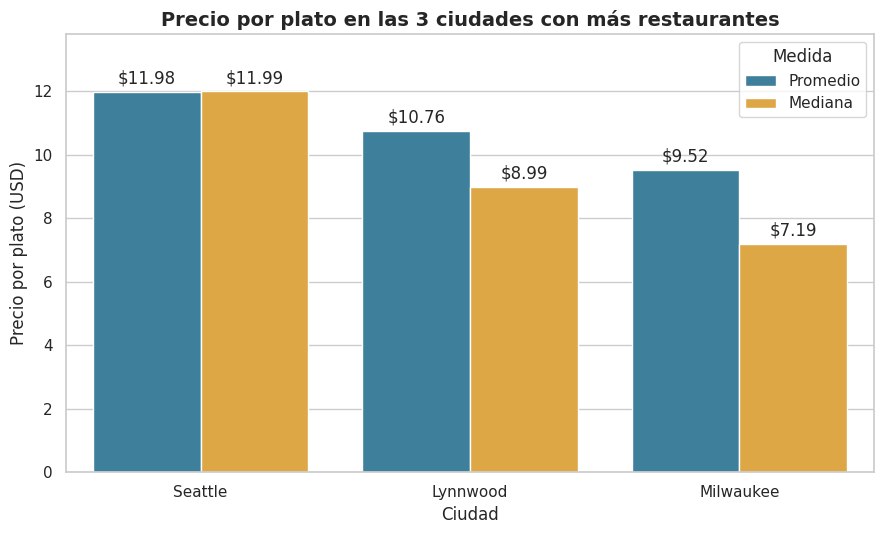

In [0]:
# Armo una tabla con el promedio y la mediana de cada ciudad para compararlos en el mismo gráfico
medianas = (
    df_master[df_master["ciudad"].isin(df_q3["ciudad"])]
    .groupby("ciudad")["price"].median().round(2)
    .rename("mediana")
    .reset_index()
)
df_q3_graf = df_q3.merge(medianas, on="ciudad")  # mantiene el orden de df_q3 (Seattle primero)

# Paso a formato largo (una fila por ciudad y medida), que es lo que seaborn necesita para barras agrupadas
df_largo = df_q3_graf.melt(
    id_vars="ciudad",
    value_vars=["precio_promedio", "mediana"],
    var_name="medida",
    value_name="precio"
)
df_largo["medida"] = df_largo["medida"].replace({"precio_promedio": "Promedio", "mediana": "Mediana"})

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(data=df_largo, x="ciudad", y="precio", hue="medida",
                 palette={"Promedio": "#2E86AB", "Mediana": "#F6AE2D"})

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="$%.2f", padding=3)  # el valor sobre cada barra

ax.set_ylim(0, df_largo["precio"].max() * 1.15)  # dejo espacio arriba para que no se corten las etiquetas
plt.title("Precio por plato en las 3 ciudades con más restaurantes", fontsize=14, fontweight="bold")
plt.xlabel("Ciudad")
plt.ylabel("Precio por plato (USD)")
plt.legend(title="Medida")
plt.tight_layout()
plt.show()

💡 **Conclusión para el CEO:** Seattle es la ciudad más cara para comer, el plato cuesta en promedio $11.98, frente a $10.76 en Lynnwood y $9.52 en Milwaukee, y la mediana confirma el mismo orden.

### ⭐ Pregunta 4: La pregunta del millón (correlación precio-calidad)
¿Un restaurante más caro garantiza una mejor experiencia? Calculo el puntaje promedio por rango de precios. El `score` es de cada restaurante y se repite en todos sus platos, así que primero me quedo con un registro por restaurante y después promedio; si no, los restaurantes con menús grandes pesarían más. Dejo fuera los 60 restaurantes sin rango de precio.

In [0]:
# Pregunta 4: puntaje promedio por rango de precios, contando cada restaurante una sola vez
query_q4 = """
WITH restaurantes AS (                    -- un registro por restaurante, no por plato
    SELECT DISTINCT id, price_range, score
    FROM master_food_data
    WHERE price_range IS NOT NULL         -- sin rango de precio no puedo ubicarlo en una categoría
)
SELECT
    price_range            AS rango_de_precios,
    COUNT(*)               AS restaurantes,     -- cuántos restaurantes respaldan cada promedio
    ROUND(AVG(score), 2)   AS score_promedio
FROM restaurantes
GROUP BY price_range
ORDER BY CASE price_range                 -- orden lógico, no alfabético
    WHEN 'Económico' THEN 1
    WHEN 'Moderadamente caro' THEN 2
    WHEN 'Caro' THEN 3
    WHEN 'Muy caro' THEN 4 END
"""

print(query_q4)  # muestro el query ejecutado

with engine.connect() as conn:
    df_q4 = pd.read_sql(text(query_q4), conn)

df_q4


WITH restaurantes AS (                    -- un registro por restaurante, no por plato
    SELECT DISTINCT id, price_range, score
    FROM master_food_data
    WHERE price_range IS NOT NULL         -- sin rango de precio no puedo ubicarlo en una categoría
)
SELECT
    price_range            AS rango_de_precios,
    COUNT(*)               AS restaurantes,     -- cuántos restaurantes respaldan cada promedio
    ROUND(AVG(score), 2)   AS score_promedio
FROM restaurantes
GROUP BY price_range
ORDER BY CASE price_range                 -- orden lógico, no alfabético
    WHEN 'Económico' THEN 1
    WHEN 'Moderadamente caro' THEN 2
    WHEN 'Caro' THEN 3
    WHEN 'Muy caro' THEN 4 END



,rango_de_precios,restaurantes,score_promedio
0,Económico,450,4.62
1,Moderadamente caro,157,4.64
2,Caro,4,4.45


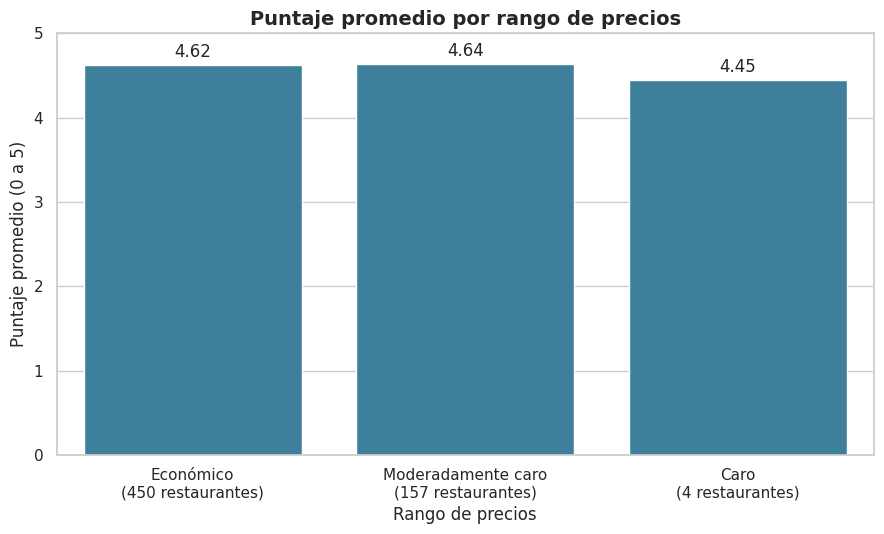

In [0]:
# Pongo la cantidad de restaurantes en cada etiqueta del eje X, para que se vea cuántos datos hay detrás
df_q4["etiqueta"] = df_q4["rango_de_precios"] + "\n(" + df_q4["restaurantes"].astype(str) + " restaurantes)"

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(data=df_q4, x="etiqueta", y="score_promedio", color="#2E86AB")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)  # el puntaje exacto sobre cada barra

ax.set_ylim(0, 5)  # empiezo en 0 y termino en 5 para no exagerar diferencias pequeñas
plt.title("Puntaje promedio por rango de precios", fontsize=14, fontweight="bold")
plt.xlabel("Rango de precios")
plt.ylabel("Puntaje promedio (0 a 5)")
plt.tight_layout()
plt.show()

💡 **Conclusión para el CEO:** Un precio más alto no garantiza mejor calidad: Económico (4.62) y Moderadamente caro (4.64) tienen casi el mismo puntaje, y Caro (4.45) se basa en solo 4 restaurantes, muy pocos para sacar una tendencia.

#### 🔍 Verificación de la Pregunta 4
Comparo el resultado con el promedio calculado por plato. La diferencia es mínima (entre 0.01 y 0.02) porque en esta muestra los restaurantes tienen menús de tamaño parecido, pero por restaurante es el cálculo correcto, ya que `score` pertenece al restaurante y no al plato.

In [0]:
# Control: así habría salido el promedio si lo hubiera calculado sobre los platos y no sobre los restaurantes
query_control = """
SELECT
    price_range AS rango_de_precios,
    ROUND(AVG(score), 2) AS score_por_plato,  -- cada restaurante pesa según cuántos platos tiene
    COUNT(*) AS platos
FROM master_food_data
WHERE price_range IS NOT NULL
GROUP BY price_range
"""

with engine.connect() as conn:
    df_control = pd.read_sql(text(query_control), conn)

df_control

,rango_de_precios,score_por_plato,platos
0,Caro,4.43,308
1,Económico,4.61,42700
2,Moderadamente caro,4.62,14994


# ✅ Conclusiones finales para el CEO
- **Geografía:** Milwaukee (123 restaurantes) y Seattle (119) lideran dentro de la muestra; las otras tres ciudades del top 5 (Lynnwood, Everett y Bellevue) también están en Washington.
- **Precios:** El mercado no es caro, el 67 % de los restaurantes es Económico y el 23 % Moderadamente caro. Solo 4 son Caros y ninguno es Muy caro.
- **Menú por ciudad:** Seattle es la ciudad más cara para comer ($11.98 por plato en promedio), seguida de Lynnwood ($10.76) y Milwaukee ($9.52).
- **Precio y calidad:** Un precio más alto no garantiza mejor experiencia; Económico (4.62) y Moderadamente caro (4.64) tienen casi el mismo puntaje.

### ⚠️ Alcance de estos resultados
Todo se calculó sobre una muestra de **671 restaurantes consolidados** (más de 100 calificaciones) que tienen menú en los archivos entregados. El 96 % está en Washington y Wisconsin, así que no representa todo el mercado de Estados Unidos y estos hallazgos sirven como una primera señal: conviene confirmarlos con datos más completos antes de decidir en qué ciudades invertir.